# Predicción del coste del seguro médico de una persona 

In [2]:
import json
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

total_data = pd.read_csv(url)

total_data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 2: Exploración y limpieza de datos

In [3]:
# Obtener las dimensiones
total_data.shape

(1338, 7)

In [4]:
# Obtener información de las columnas con valores nulos
total_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

El dataset está completo, sin huecos que rellenar.

## PASO 3: Análisis de variables univariante

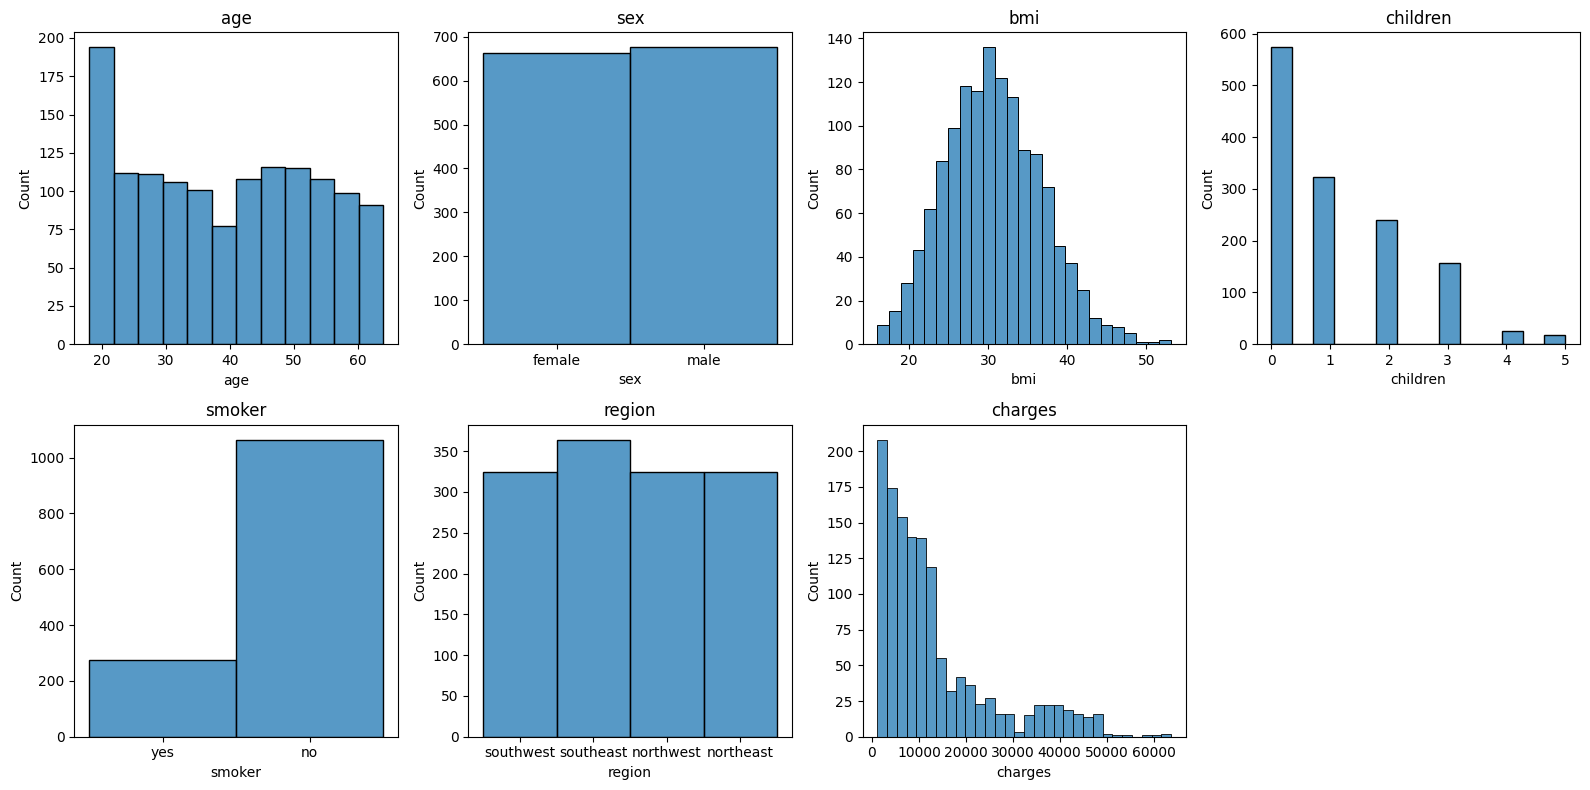

In [8]:
fig, axis = plt.subplots(2, 4, figsize=(16, 8))

variables = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]

# Dibujar cada histograma en su subplot
for i, var in enumerate(variables):
    fila = i // 4
    col = i % 4
    sns.histplot(ax = axis[fila, col], data = total_data, x = var)
    axis[fila, col].set_title(var)

# Ocultar el subplot vacío (el 8º)
axis[1,3].axis("off")

plt.tight_layout()
plt.show()

De las variables que encontramos:
Age = Edad del beneficiario principal (numérico)
Sex = Género del beneficiario principal (categórico)
BMI = índice de masa corporal (numérico)
Children = Número de niños/dependientes cubiertos por un seguro médico (numérico)
Smoker = ¿Es fumador? (categórico)
Region = Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
Charges = Prima del seguro médico (numérico)

Análisis de variables numéricas

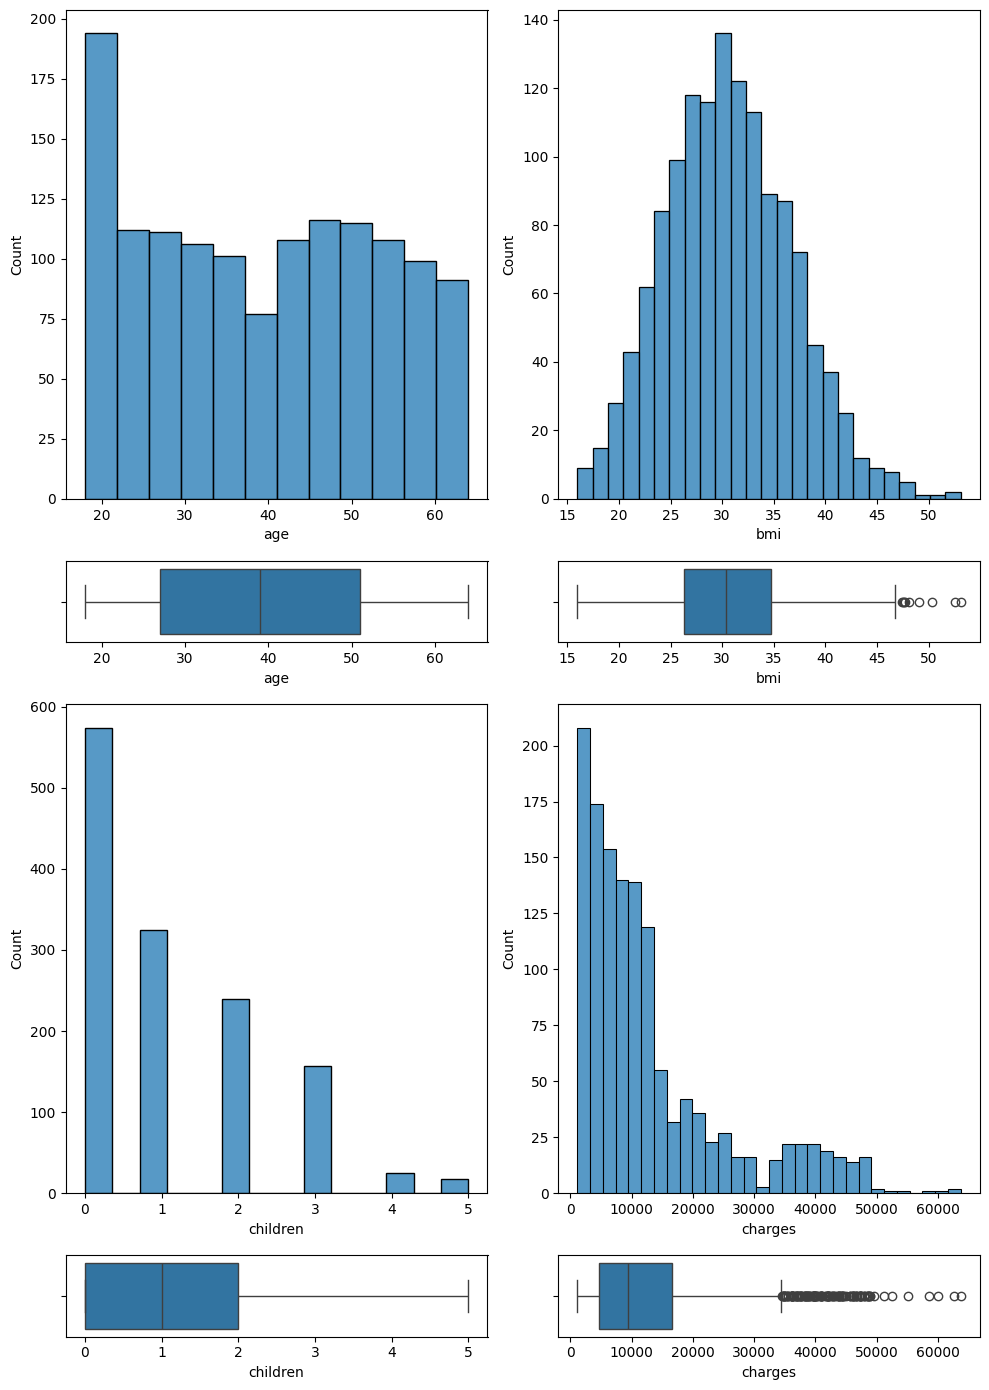

In [9]:
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "age")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "age")

sns.histplot(ax = axis[0, 1], data = total_data, x = "bmi")
sns.boxplot(ax = axis[1, 1], data = total_data, x = "bmi")

sns.histplot(ax = axis[2, 0], data = total_data, x = "children")
sns.boxplot(ax = axis[3, 0], data = total_data, x = "children")

sns.histplot(ax = axis[2,1], data = total_data, x = "charges")
sns.boxplot(ax = axis[3, 1], data = total_data, x = "charges")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Age :La población está bien distribuida, pero ligeramente inclinada hacia edades jóvenes. Esto puede influir en los costes, ya que personas jóvenes suelen tener menos gastos médicos.
BMI o Índice de Masa Corporal: La mayoría de personas tienen un BMI entre 25 y 35 (sobrepeso). Los valores altos pueden ser importantes porque el BMI suele correlacionar con mayores costes médicos.
Children: La distribución es muy sesgada a la izquierda por lo que en sy mayoría tiene 0 hijos, luego 1 o 2, y muy pocos tienen más de 3.
Charges: Los costes médicos no siguen una distribución normal. Hay muchos casos baratos y pocos casos extremadamente caros. Esto es típico en seguros médicos y sugiere transformaciones (como logaritmos) para modelos lineales.

# Paso 4: Análisis de Variable Multivariante

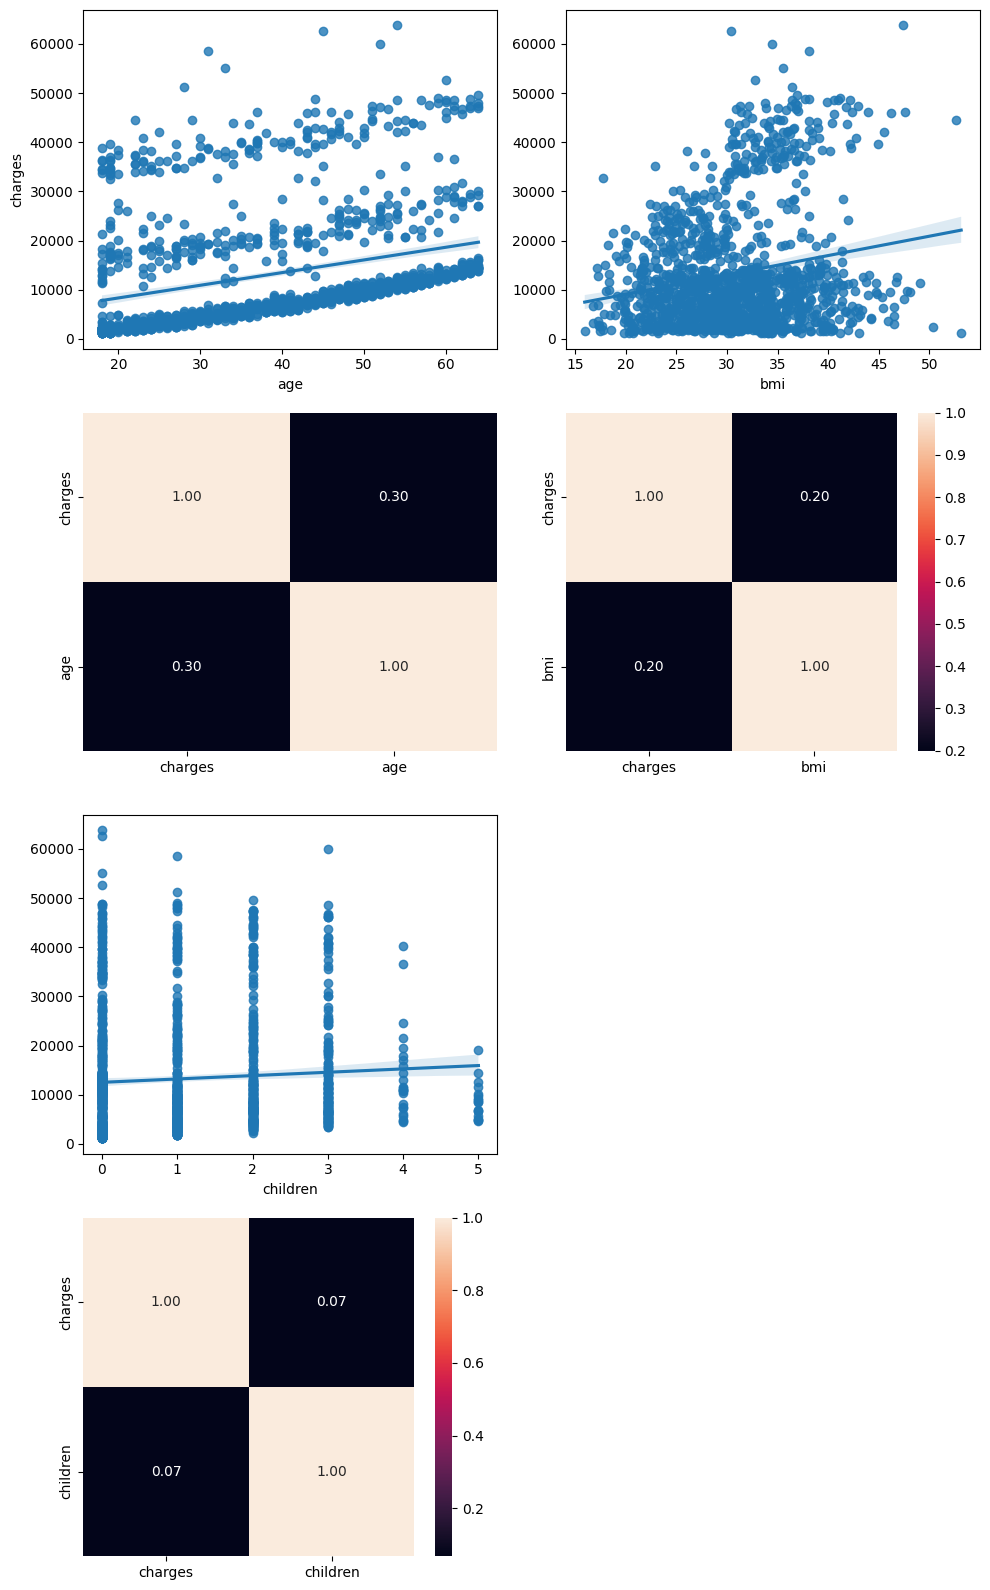

In [10]:
# Numerical - Numerical Analysis

# Create subplot canvas
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

# Create Plates
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "charges")
sns.heatmap(total_data[["charges", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "bmi", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "children", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "children"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Age	tiene una correlación de ~0.30 CON	Influencia moderada, útil para el modelo.

BMI	tiene una correlación de ~0.20	CON Influencia débil, aporta algo de información.

Children tiene una correlación de ~0.07	CON Influencia muy baja, casi irrelevante

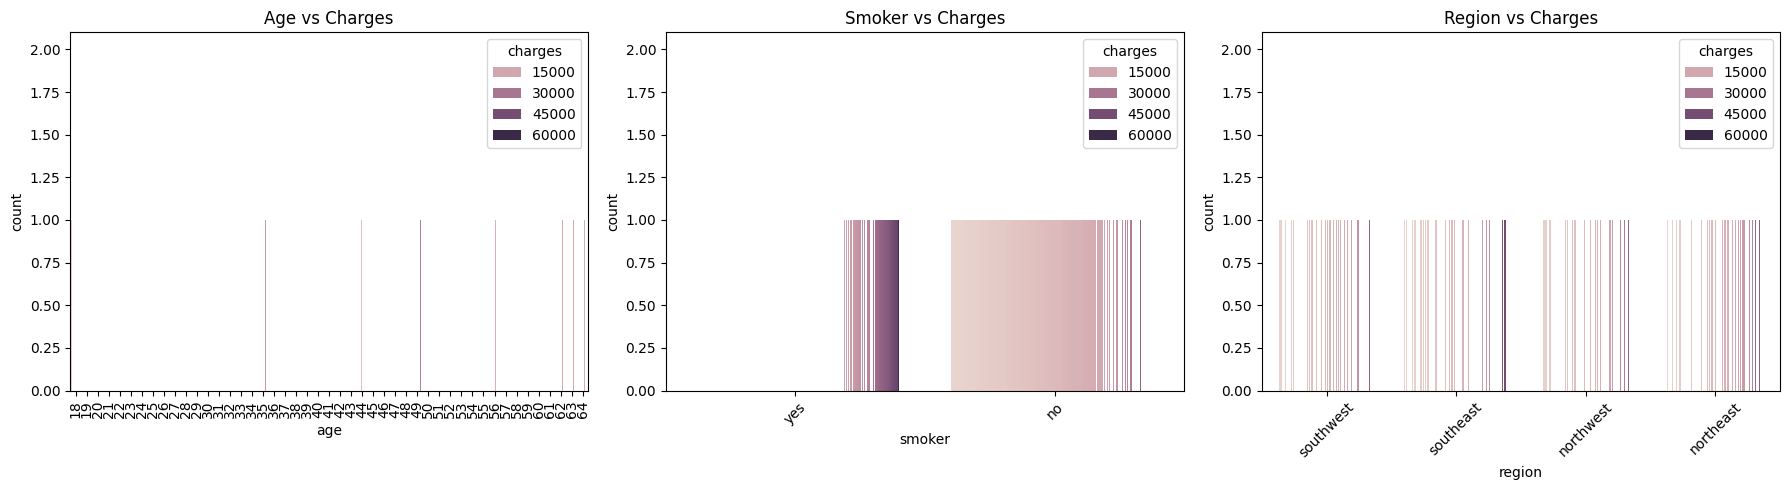

In [16]:
# Crear figura y ejes (3 gráficos → 1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1
sns.countplot(
    ax=axes[0],
    data=total_data,
    x="age",
    hue="charges"
)
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title("Age vs Charges")

# Gráfico 2
sns.countplot(
    ax=axes[1],
    data=total_data,
    x="smoker",
    hue="charges"
)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("Smoker vs Charges")

# Gráfico 3
sns.countplot(
    ax=axes[2],
    data=total_data,
    x="region",
    hue="charges"
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title("Region vs Charges")

plt.tight_layout()
plt.show()
